In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
df = pd.read_csv('/Users/zaheerahmad/Desktop/customer_churn_project_ml/note book/data/merged_churn_clean.csv')
pd.set_option('display.max_columns', None)

In [11]:
df.head()

,Age,Avg Monthly GB Download,Avg Monthly Long Distance Charges,Churn Category,Churn Reason,Churn Score,City,CLTV,Contract,Country,Customer ID,Customer Status,Dependents,Device Protection Plan,Gender,Internet Service,Internet Type,Lat Long,Latitude,Longitude,Married,Monthly Charge,Multiple Lines,Number of Dependents,Number of Referrals,Offer,Online Backup,Online Security,Paperless Billing,Partner,Payment Method,Phone Service,Population,Premium Tech Support,Quarter,Referred a Friend,Satisfaction Score,Senior Citizen,State,Streaming Movies,Streaming Music,Streaming TV,Tenure in Months,Total Charges,Total Extra Data Charges,Total Long Distance Charges,Total Refunds,Total Revenue,Under 30,Unlimited Data,Zip Code,Churn
0,72,4,19.44,NaN,NaN,51,San Mateo,4849,Two Year,United States,4526-ZJJTM,Stayed,0,1,Female,1,Fiber Optic,"37.538309, -122.305109",37.538309,-122.305109,1,88.40,0,0,1,NaN,1,0,0,1,Bank Withdrawal,1,37926,0,Q3,1,3,1,California,1,1,0,25,2191.15,0,486.00,0.0,2677.15,0,1,94403,0
1,27,59,45.62,NaN,NaN,27,Sutter Creek,3715,Month-to-Month,United States,5302-BDJNT,Stayed,0,1,Male,1,Fiber Optic,"38.432145, -120.77069",38.432145,-120.770690,0,95.50,1,0,0,NaN,0,0,0,0,Bank Withdrawal,1,4610,1,Q3,0,3,0,California,0,0,1,35,3418.20,0,1596.70,0.0,5014.90,1,1,95685,0
2,59,0,16.07,NaN,NaN,59,Santa Cruz,5092,Month-to-Month,United States,5468-BPMMO,Stayed,0,0,Male,0,NaN,"37.007882, -122.065975",37.007882,-122.065975,1,19.60,0,0,3,NaN,0,0,0,1,Bank Withdrawal,1,4563,0,Q3,1,5,0,California,0,0,0,46,851.20,0,739.22,0.0,1590.42,0,0,95064,0
3,25,27,0.00,NaN,NaN,49,Brea,2068,One Year,United States,2212-LYASK,Stayed,0,1,Male,1,DSL,"33.924143, -117.79387",33.924143,-117.793870,1,45.85,0,0,3,NaN,1,0,1,1,Credit Card,0,1408,0,Q3,1,4,0,California,1,1,0,27,1246.40,30,0.00,0.0,1276.40,1,0,92823,0
4,31,21,17.22,Dissatisfaction,Network reliability,88,San Jose,4026,One Year,United States,0378-XSZPU,Churned,0,1,Male,1,Cable,"37.311088, -121.961786",37.311088,-121.961786,1,60.30,0,0,1,Offer B,1,1,0,1,Credit Card,1,29914,0,Q3,1,2,0,California,0,0,0,58,3563.80,0,998.76,0.0,4562.56,0,1,95117,1


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 52 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                7043 non-null   int64  
 1   Avg Monthly GB Download            7043 non-null   int64  
 2   Avg Monthly Long Distance Charges  7043 non-null   float64
 3   Churn Category                     1869 non-null   object 
 4   Churn Reason                       1869 non-null   object 
 5   Churn Score                        7043 non-null   int64  
 6   City                               7043 non-null   object 
 7   CLTV                               7043 non-null   int64  
 8   Contract                           7043 non-null   object 
 9   Country                            7043 non-null   object 
 10  Customer ID                        7043 non-null   object 
 11  Customer Status                    7043 non-null   objec

In [13]:
df.isna().sum()

Age                                     0
Avg Monthly GB Download                 0
Avg Monthly Long Distance Charges       0
Churn Category                       5174
Churn Reason                         5174
Churn Score                             0
City                                    0
CLTV                                    0
Contract                                0
Country                                 0
Customer ID                             0
Customer Status                         0
Dependents                              0
Device Protection Plan                  0
Gender                                  0
Internet Service                        0
Internet Type                        1526
Lat Long                                0
Latitude                                0
Longitude                               0
Married                                 0
Monthly Charge                          0
Multiple Lines                          0
Number of Dependents              

In [15]:
num_df = df.select_dtypes(include=['number'])
corr_with_target = num_df.corr().abs()["Churn"]
churn_score = corr_with_target.sort_values(ascending=False)

selected_cols = churn_score[churn_score > 0.1].index

import numpy as np

corr_matrix = num_df[selected_cols].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]

final_features = [col for col in selected_cols if col not in to_drop]
X = num_df[final_features].drop(columns=["Churn"], errors='ignore')
y = num_df["Churn"]
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X, y)

importances = model.feature_importances_
feature_importance = sorted(zip(X.columns, importances), key=lambda x: x[1], reverse=True)

feature_importance

[('Satisfaction Score', np.float64(0.5063691844195699)),
 ('Churn Score', np.float64(0.29183290550926416)),
 ('Tenure in Months', np.float64(0.049047921823167216)),
 ('Monthly Charge', np.float64(0.031111740946530193)),
 ('Total Long Distance Charges', np.float64(0.02673965698847781)),
 ('Number of Referrals', np.float64(0.021592546945368565)),
 ('CLTV', np.float64(0.014571046500081744)),
 ('Age', np.float64(0.013016105358112403)),
 ('Dependents', np.float64(0.01085256873840533)),
 ('Internet Service', np.float64(0.010411938612126692)),
 ('Online Security', np.float64(0.009646212553970688)),
 ('Paperless Billing', np.float64(0.004344864395946666)),
 ('Premium Tech Support', np.float64(0.0033364933340483587)),
 ('Unlimited Data', np.float64(0.002957720958827198)),
 ('Partner', np.float64(0.0025339870922646813)),
 ('Senior Citizen', np.float64(0.0016351058238384586))]

In [16]:
top_features = [f[0] for f in feature_importance[:10]]
X_final = X[top_features]
data = X_final

In [17]:
data.head(10)

,Satisfaction Score,Churn Score,Tenure in Months,Monthly Charge,Total Long Distance Charges,Number of Referrals,CLTV,Age,Dependents,Internet Service
0,3,51,25,88.40,486.00,1,4849,72,0,1
1,3,27,35,95.50,1596.70,0,3715,27,0,1
2,5,59,46,19.60,739.22,3,5092,59,0,0
3,4,49,27,45.85,0.00,3,2068,25,0,1
4,2,88,58,60.30,998.76,1,4026,31,0,1
5,1,81,3,100.95,35.82,0,5351,32,0,1
6,3,77,24,89.25,245.52,2,5436,36,0,1
7,2,79,63,100.55,565.74,3,5413,48,0,1
8,5,75,72,111.65,3226.32,0,5388,72,0,1
9,4,78,2,60.95,29.76,0,3172,54,1,1


In [18]:
data.isna().sum()

Satisfaction Score             0
Churn Score                    0
Tenure in Months               0
Monthly Charge                 0
Total Long Distance Charges    0
Number of Referrals            0
CLTV                           0
Age                            0
Dependents                     0
Internet Service               0
dtype: int64

In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Satisfaction Score           7043 non-null   int64  
 1   Churn Score                  7043 non-null   int64  
 2   Tenure in Months             7043 non-null   int64  
 3   Monthly Charge               7043 non-null   float64
 4   Total Long Distance Charges  7043 non-null   float64
 5   Number of Referrals          7043 non-null   int64  
 6   CLTV                         7043 non-null   int64  
 7   Age                          7043 non-null   int64  
 8   Dependents                   7043 non-null   int64  
 9   Internet Service             7043 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 550.4 KB


In [23]:
gender = df['Gender']
y

0       0
1       0
2       0
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [25]:
df1 = pd.concat([data,gender,y],axis=1)

In [64]:
df1.head()

,Satisfaction Score,Churn Score,Tenure in Months,Monthly Charge,Total Long Distance Charges,Number of Referrals,CLTV,Age,Dependents,Internet Service,Gender,Churn
0,3,51,25,88.40,486.00,1,4849,72,0,1,Female,0
1,3,27,35,95.50,1596.70,0,3715,27,0,1,Male,0
2,5,59,46,19.60,739.22,3,5092,59,0,0,Male,0
3,4,49,27,45.85,0.00,3,2068,25,0,1,Male,0
4,2,88,58,60.30,998.76,1,4026,31,0,1,Male,1


In [65]:
df1.to_csv("customer_churn_updated.csv",index=False)

In [31]:
X = df1.drop(columns=['Churn'])
y = df1['Churn']

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [37]:
y_train.value_counts()

Churn
0    3636
1    1294
Name: count, dtype: int64

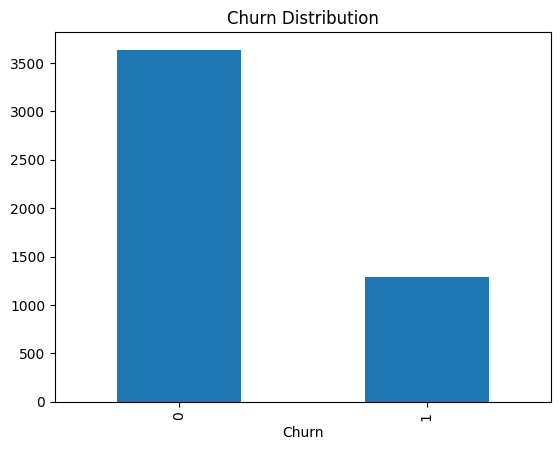

In [38]:
y_train.value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.show()

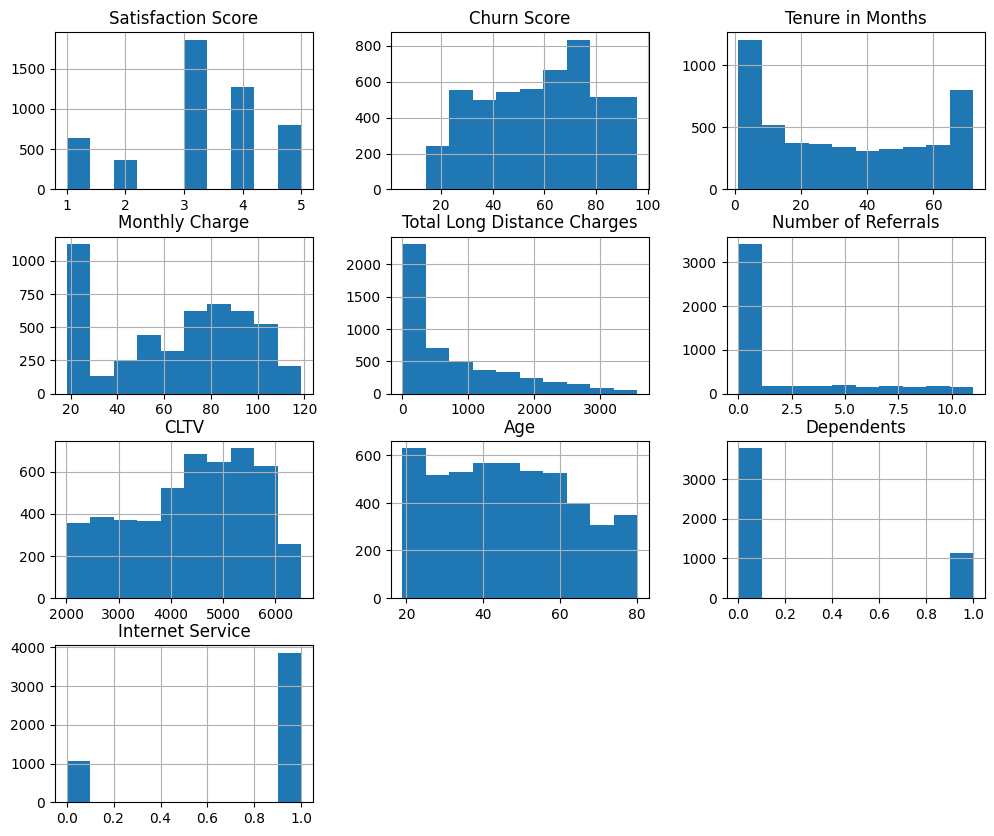

In [39]:
X_train.hist(figsize=(12,10))
plt.show()

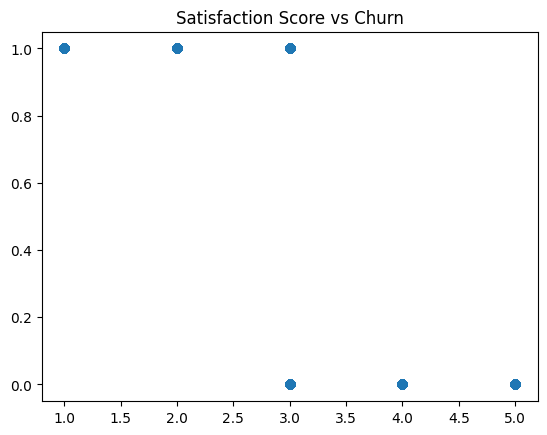

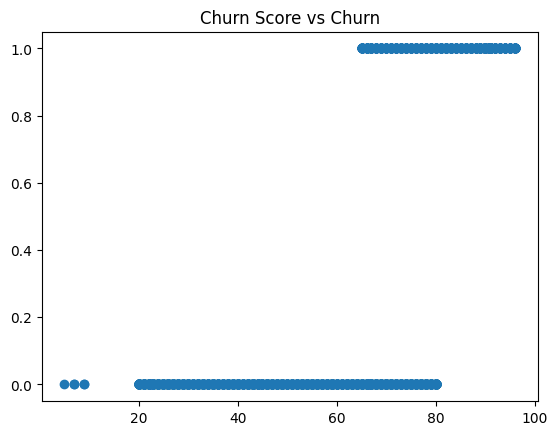

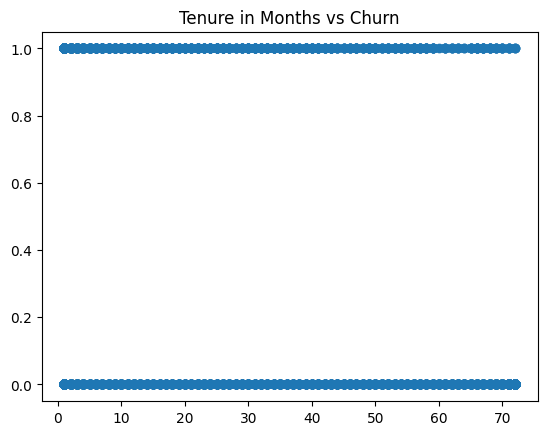

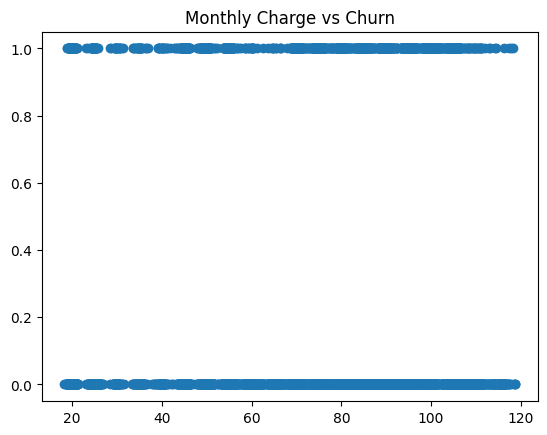

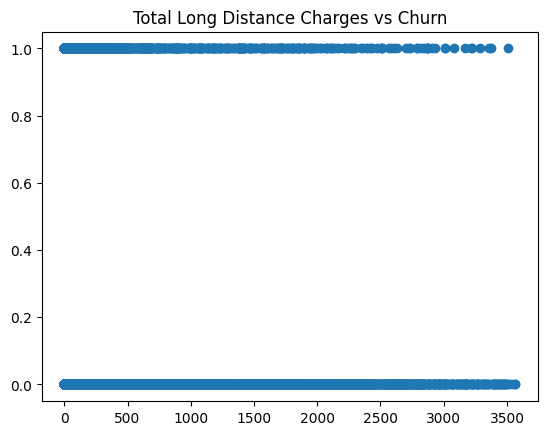

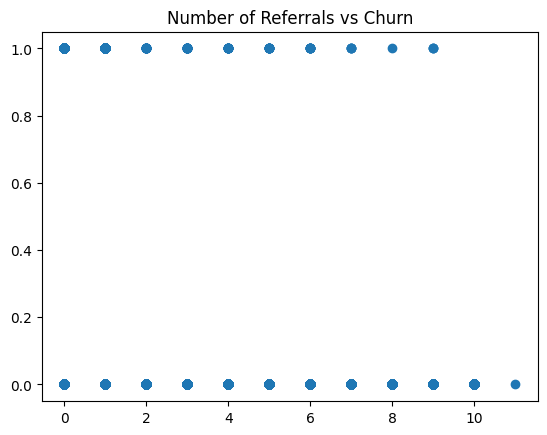

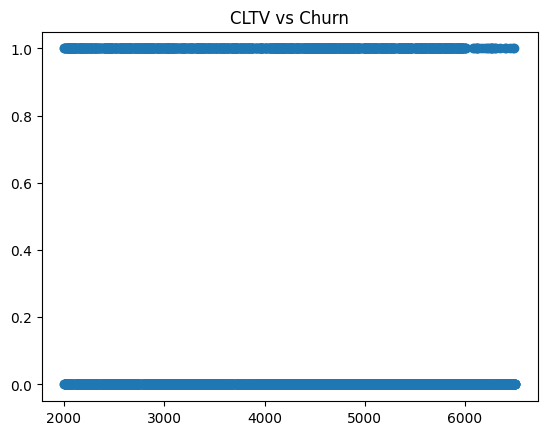

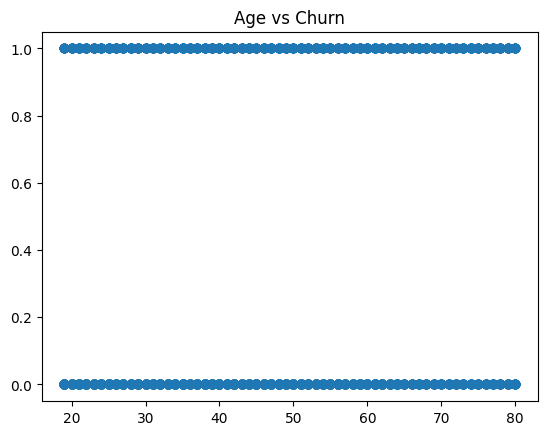

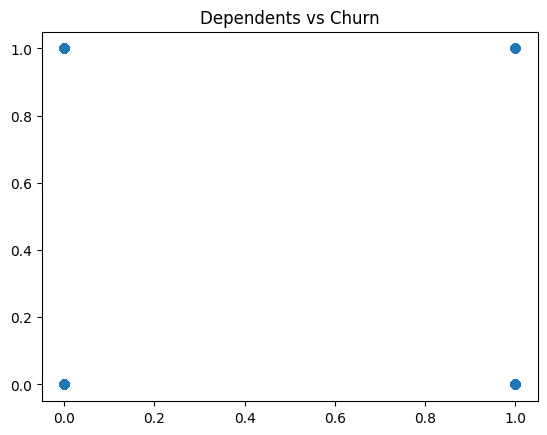

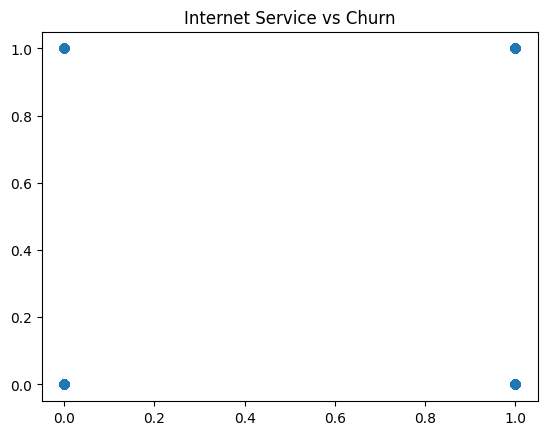

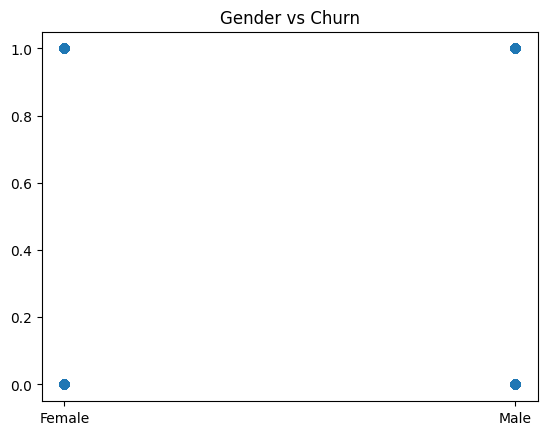

In [41]:
for col in X_train.columns:
  plt.scatter(X_train[col],y_train)
  plt.title(f"{col} vs Churn")
  plt.show()

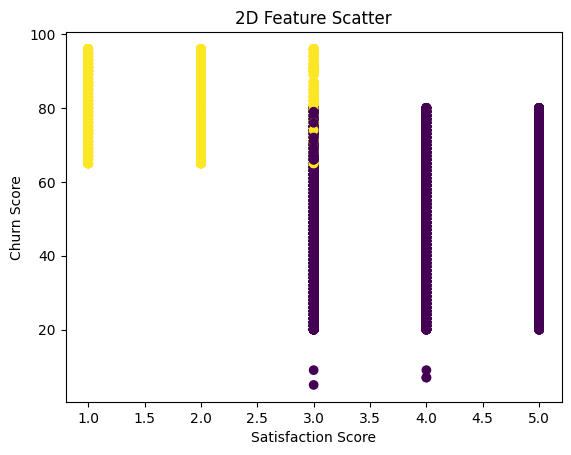

In [45]:
plt.scatter(
    X_train.iloc[:, 0], 
    X_train.iloc[:, 1], 
    c=y_train
)

plt.xlabel(X_train.columns[0])
plt.ylabel(X_train.columns[1])
plt.title("2D Feature Scatter")
plt.show()

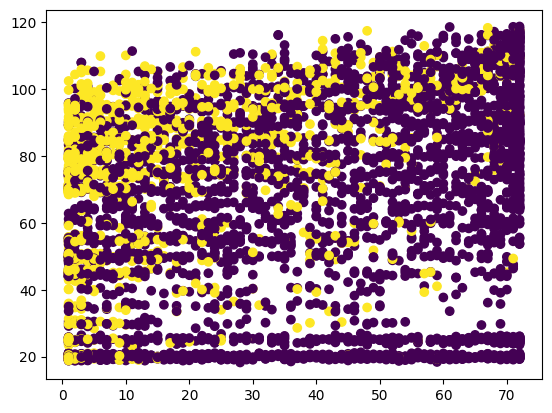

In [46]:
plt.scatter(X_train.iloc[:, 2], X_train.iloc[:, 3], c=y_train)
plt.show()

In [48]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [49]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    
    "DecisionTree": DecisionTreeClassifier(class_weight="balanced"),
    
    "RandomForest": RandomForestClassifier(class_weight="balanced", n_estimators=200),
    
    "GradientBoosting": GradientBoostingClassifier(),
    
    "AdaBoost": AdaBoostClassifier(),
    
    "SVM (RBF)": SVC(kernel='rbf', class_weight="balanced"),
    
    "KNN": KNeighborsClassifier()
}

In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [56]:
num_col = ['Satisfaction Score',
 'Churn Score',
 'Tenure in Months',
 'Monthly Charge',
 'Total Long Distance Charges',
 'Number of Referrals',
 'CLTV',
 'Age',
 'Dependents',
 'Internet Service']
cat_col = ['Gender']

In [57]:
num_col_pipeline = Pipeline(
    steps=[
        ("simpleimputer",SimpleImputer(strategy="median")),
        ("standarsclaer",StandardScaler())
    ]
)
cat_col_pipeline = Pipeline(
   steps=
         [
          ("imputer",SimpleImputer(strategy="most_frequent")),
          ("onehotenoder",OneHotEncoder()),
          ("standardscaler",StandardScaler(with_mean=False))
          ]
)

In [58]:
preprocess = ColumnTransformer(
    [
        ("num",num_col_pipeline,num_col),
        ("cat",cat_col_pipeline,cat_col)
    ]
)

In [59]:
X_train = preprocess.fit_transform(X_train)
X_test = preprocess.transform(X_test)

In [60]:
X_test

array([[ 0.62544035,  0.45825622, -1.20566885, ...,  0.52618559,
         2.00029038,  0.        ],
       [ 0.62544035, -0.52944554, -0.71893215, ...,  0.52618559,
         0.        ,  2.00029038],
       [-1.04352902,  1.21079088, -1.28679163, ..., -1.90047013,
         2.00029038,  0.        ],
       ...,
       [-0.20904434, -0.90571287,  1.59306716, ...,  0.52618559,
         2.00029038,  0.        ],
       [-0.20904434,  0.78749013,  0.53847098, ...,  0.52618559,
         0.        ,  2.00029038],
       [-0.20904434,  1.5400248 , -1.20566885, ...,  0.52618559,
         2.00029038,  0.        ]], shape=(2113, 12))

In [62]:
from sklearn.metrics import accuracy_score
score1 = {}
for i in range(len(list(models))):
  model = list(models.values())[i]
  model.fit(X_train,y_train)
  y_pred = model.predict(X_test)
  accuracy = accuracy_score(y_test,y_pred)
  score1[list(models.keys())[i]] = accuracy

In [63]:
score1

{'LogisticRegression': 0.9663984855655466,
 'DecisionTree': 0.9687647893989588,
 'RandomForest': 0.9801230477993375,
 'GradientBoosting': 0.9810695693327023,
 'AdaBoost': 0.975390440132513,
 'SVM (RBF)': 0.966871746332229,
 'KNN': 0.95929957406531}

In [66]:
df2 = pd.read_csv('/Users/zaheerahmad/Desktop/customer_churn_project_ml/note book/customer_churn_updated.csv')
df2.head()

,Satisfaction Score,Churn Score,Tenure in Months,Monthly Charge,Total Long Distance Charges,Number of Referrals,CLTV,Age,Dependents,Internet Service,Gender,Churn
0,3,51,25,88.40,486.00,1,4849,72,0,1,Female,0
1,3,27,35,95.50,1596.70,0,3715,27,0,1,Male,0
2,5,59,46,19.60,739.22,3,5092,59,0,0,Male,0
3,4,49,27,45.85,0.00,3,2068,25,0,1,Male,0
4,2,88,58,60.30,998.76,1,4026,31,0,1,Male,1
